## Task 04
## Pick the right chart, five times (mpg.csv)
398 cars from 1970–1982. Columns: mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin, name. horsepower is missing for 6 cars.

For each question below, choose a chart type, draw it, and write one sentence justifying the choice. Different questions should not all get the same chart.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
path = "week 01 dataset/mpg.csv"
df = pd.read_csv(path)

# Check data
print("Shape:", df.shape)
display(df.head())
print(df.isna().sum())

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


## 1. More fuel-efficient 
Did cars get more fuel-efficient between 1970 and 1982?

**Chart type: Line chart**

**A line chart is appropriate because model_year is a time variable, so it clearly shows the change in average MPG over the years.**


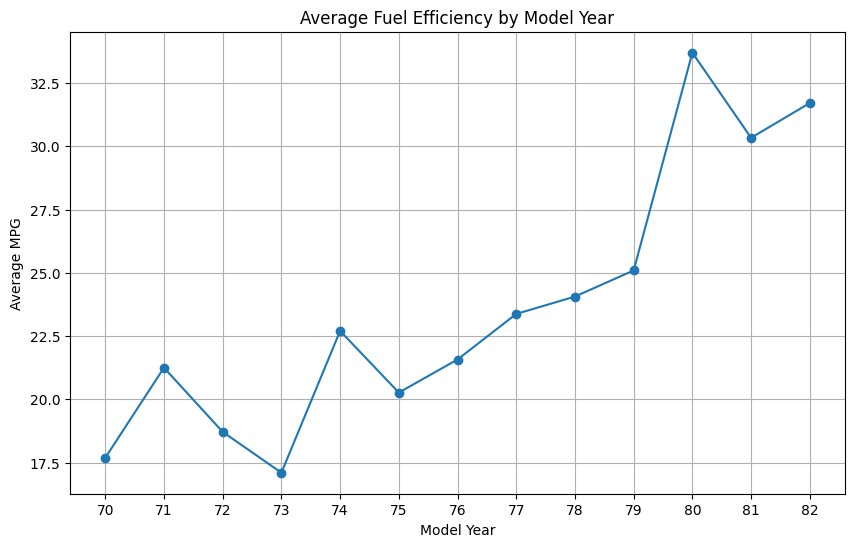

In [4]:
# Calculate average MPG for each model year
year_mpg = df.groupby("model_year")["mpg"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    year_mpg.index,
    year_mpg.values,
    marker="o"
)

plt.title("Average Fuel Efficiency by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.xticks(year_mpg.index)
plt.grid(True)

plt.show()

**Justification**

A line chart is suitable because it shows how average fuel efficiency changes continuously over model years.

The average MPG generally increases from the early 1970s toward 1982, indicating improved fuel efficiency over this period

## 2. American, European and Japanese cars
Do American, European and Japanese cars differ in fuel efficiency?

**Chart type: Box plot**

**A box plot is suitable because we want to compare the distribution of MPG across three groups.**

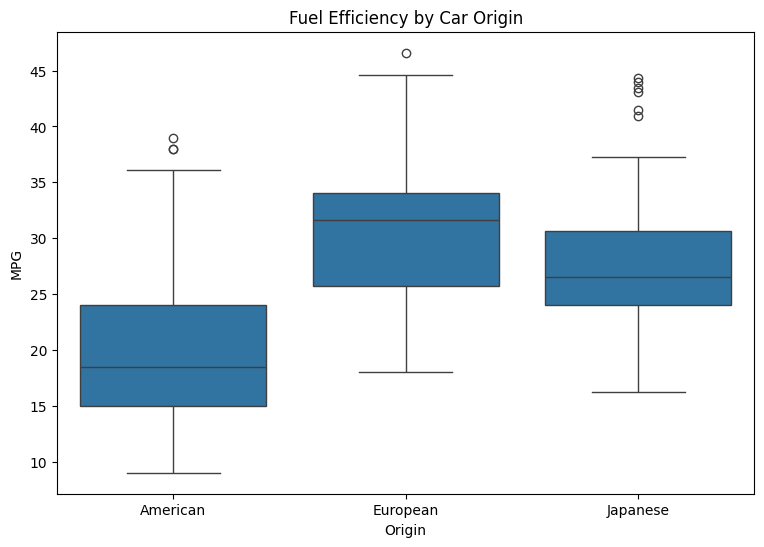

In [5]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="origin",
    y="mpg"
)

plt.title("Fuel Efficiency by Car Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")

plt.xticks(
    [0, 1, 2],
    ["American", "European", "Japanese"]
)

plt.show()

**Justification**

A box plot is appropriate because it compares the median, spread, and overall distribution of fuel efficiency between the three origins.

The groups differ noticeably in MPG. Japanese and European cars generally occupy higher MPG ranges than American cars.

## 3. Relationship
What is the relationship between a car's weight and its fuel efficiency?

**Chart type: Scatter plot**

**Both weight and mpg are numerical variables, so a scatter plot is the natural choice.**

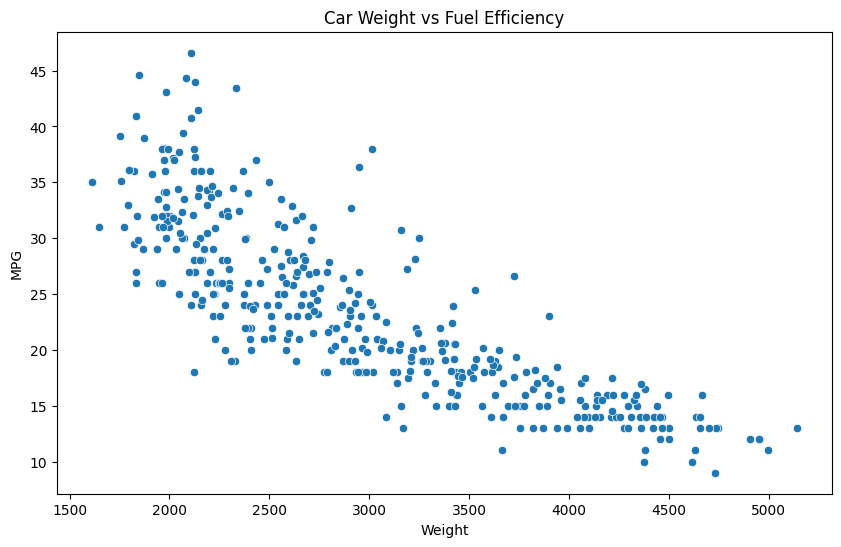

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("Car Weight vs Fuel Efficiency")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

**Justification**

A scatter plot is appropriate because it shows the relationship between two numerical variables and makes the direction and strength of the association visible.

There is a strong negative relationship:
As car weight increases, MPG generally decreases.
Heavier cars tend to be less fuel-efficient.

## 4. Number of cylinders
How is the number of cylinders distributed across the fleet?

**Chart type: Bar chart**

**The number of cylinders is a discrete categorical/count variable, so a bar chart clearly shows how many cars belong to each cylinder category.**

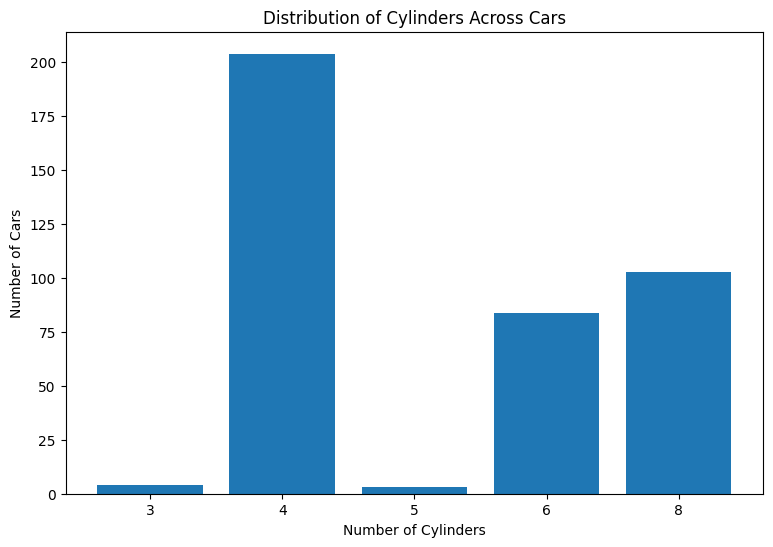

In [7]:
plt.figure(figsize=(9, 6))

cylinder_counts = df["cylinders"].value_counts().sort_index()

plt.bar(
    cylinder_counts.index.astype(str),
    cylinder_counts.values
)

plt.title("Distribution of Cylinders Across Cars")
plt.xlabel("Number of Cylinders")
plt.ylabel("Number of Cars")

plt.show()

**Justification**

A bar chart is suitable because it clearly compares the number of cars belonging to each cylinder category.

The fleet contains mainly cars with:

4 cylinders
6 cylinders
8 cylinders

with 4- and 8-cylinder cars making up substantial portions of the dataset.

## 5. Did cars get lighter
Is the improvement in question 1 explained by question 3? (i.e. did cars get lighter?)

**Chart type: Line chart**

**Here we compare average vehicle weight across model years.**

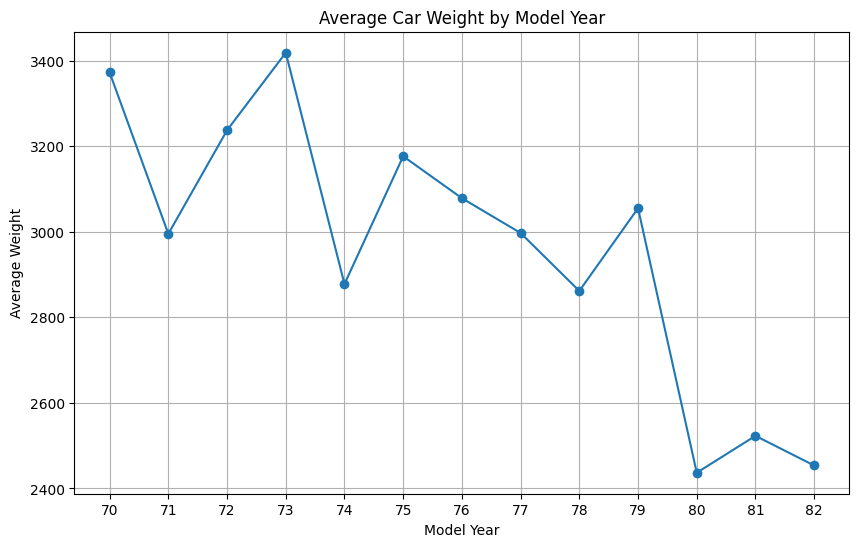

In [8]:
year_weight = df.groupby("model_year")["weight"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    year_weight.index,
    year_weight.values,
    marker="o"
)

plt.title("Average Car Weight by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average Weight")
plt.xticks(year_weight.index)
plt.grid(True)

plt.show()

**Justification**

A line chart is appropriate because it shows whether the average weight of cars changed over the same period in which fuel efficiency improved.

Average vehicle weight generally decreases over the model years, particularly from the heavier cars of the 1970s toward the lighter cars around 1980–1982.

The reduction in vehicle weight is consistent with being one important factor associated with the improvement in fuel efficiency.

However, it does not prove that weight alone caused the improvement. Other factors such as engine size, horsepower, technology, and vehicle design also changed

## Redraw the weakest chart
Take whichever of your five charts you think is the weakest and redraw it. Say what you changed.

**I would choose Question 4 (cylinder distribution) as the weakest of the five because the simple bar chart tells us the counts but doesn't make the relative proportions especially easy to compare.**

**We can improve it by adding the percentage of cars above each bar.**

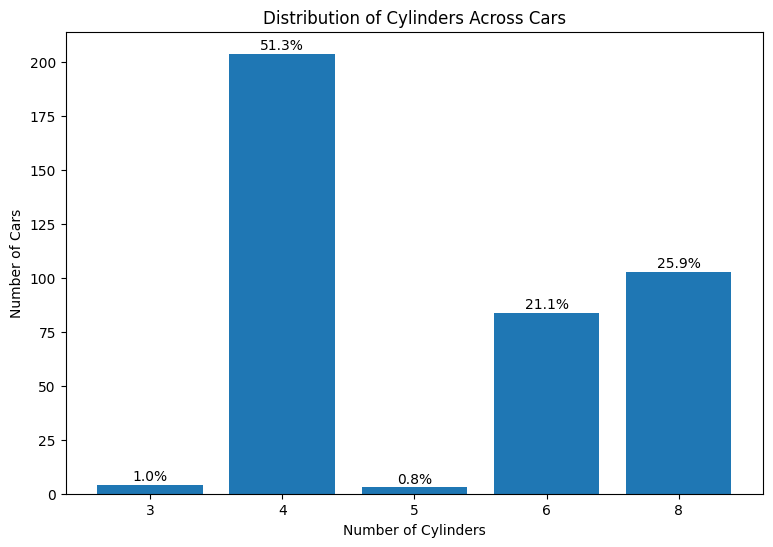

In [9]:
cylinder_counts = df["cylinders"].value_counts().sort_index()
cylinder_percent = cylinder_counts / len(df) * 100

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cylinder_counts.index.astype(str),
    cylinder_counts.values
)

plt.title("Distribution of Cylinders Across Cars")
plt.xlabel("Number of Cylinders")
plt.ylabel("Number of Cars")

# Add percentage labels
for bar, percentage in zip(bars, cylinder_percent):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{percentage:.1f}%",
        ha="center"
    )

plt.show()

I added percentage labels to the bars, making it easier to understand not only how many cars have each number of cylinders but also what proportion of the entire fleet they represent.